In [1]:
!pip install opencv-python

please upload your image file. for example, 'my_image.jpg' or 'sample.png'.


Saving gimmi3.jpg to gimmi3.jpg
file 'gimmi3.jpg' uploaded successfully.
image loaded successfully from gimmi3.jpg. image shape: (1200, 1600, 3)


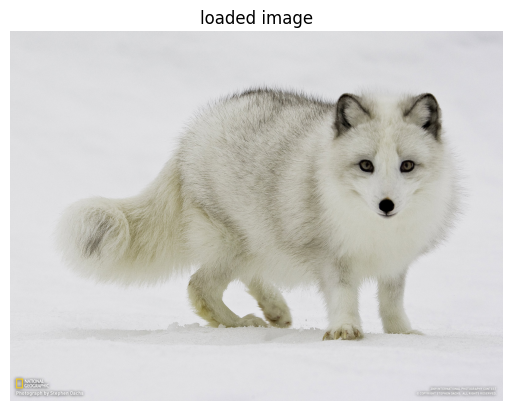

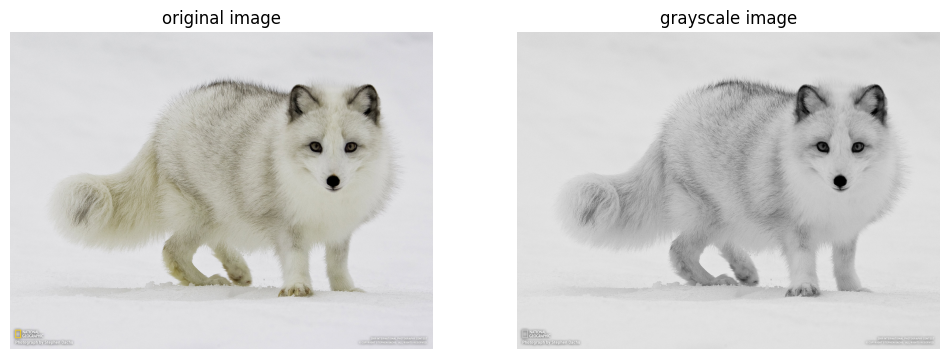

original and grayscale images displayed.
accessing pixel intensity values from the grayscale image:
pixel at (0, 0): intensity = 218
pixel at (0, 1599): intensity = 207
pixel at (1199, 0): intensity = 222
pixel at (1199, 1599): intensity = 216
pixel at (600, 800): intensity = 187
pixel intensity values accessed and printed.
original intensity of pixel (600, 800): 187
new random intensity for pixel (600, 800): 130


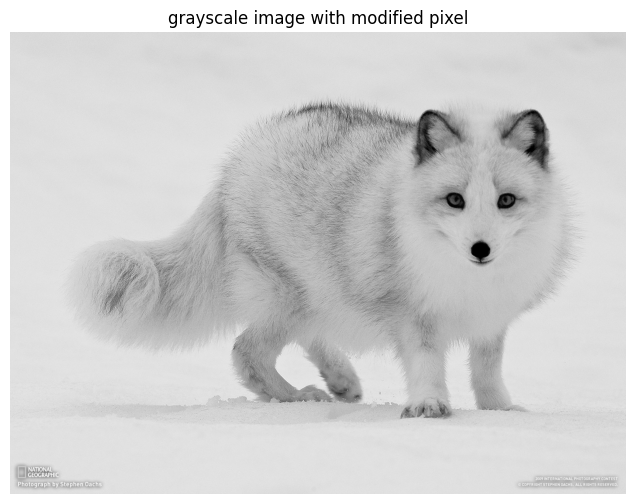

grayscale image with a modified pixel displayed.


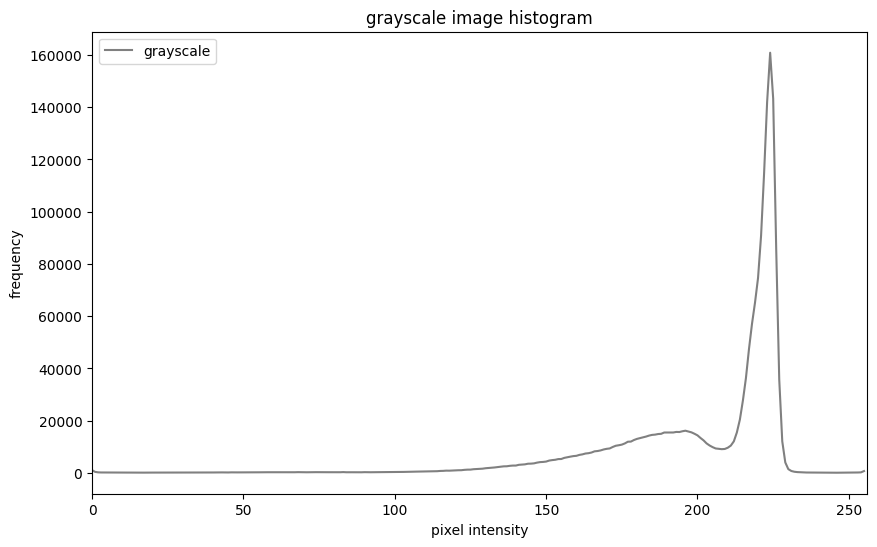

grayscale image histogram displayed.


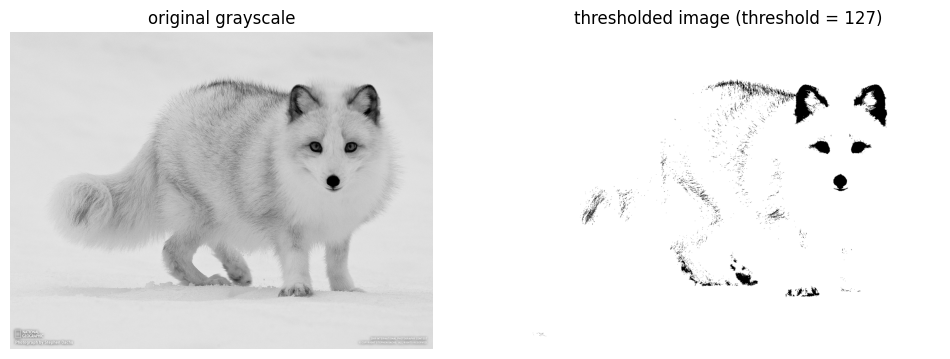

thresholding applied and images displayed.


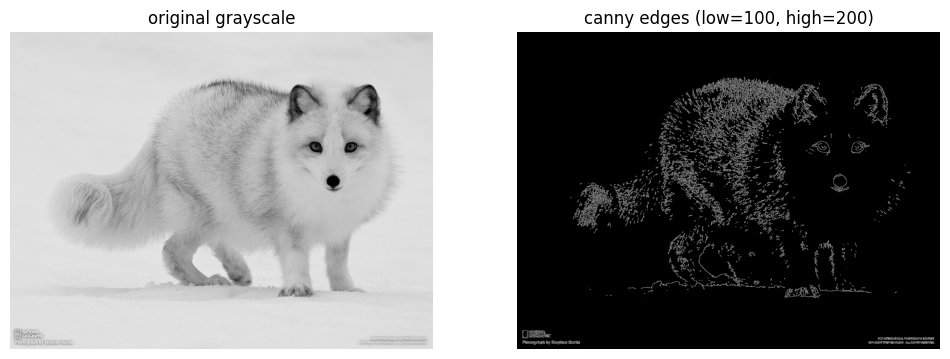

canny edge detection applied and images displayed.


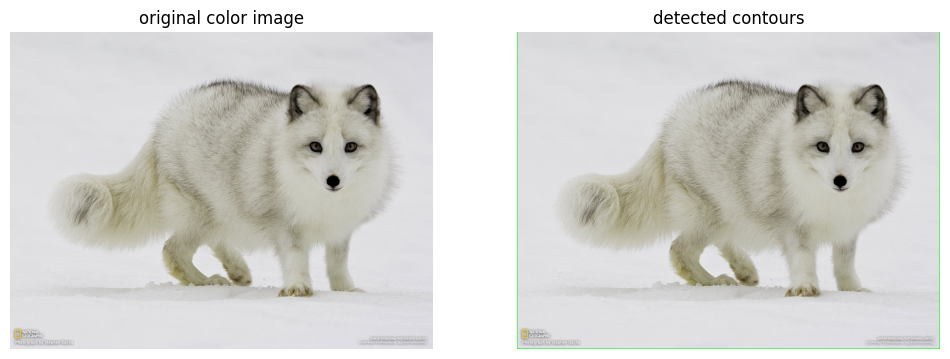

found 1 contours. image with detected contours displayed.


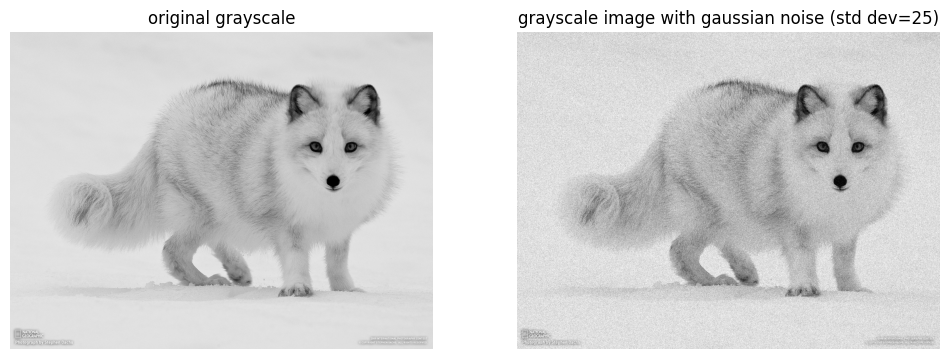

gaussian noise introduced to the grayscale image and displayed.


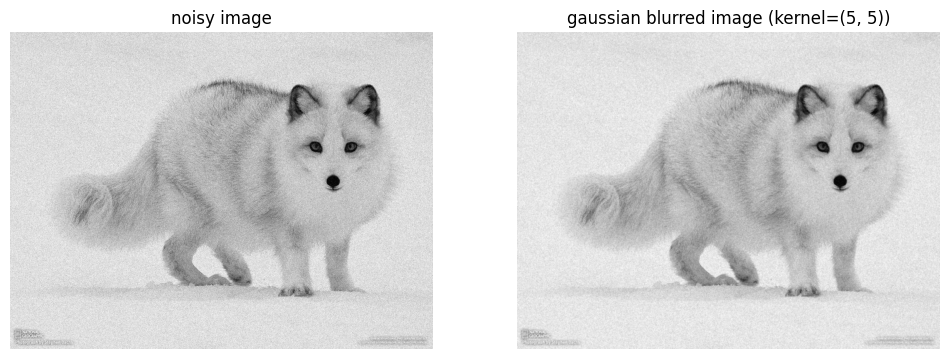

gaussian blurring applied to the noisy image and displayed.


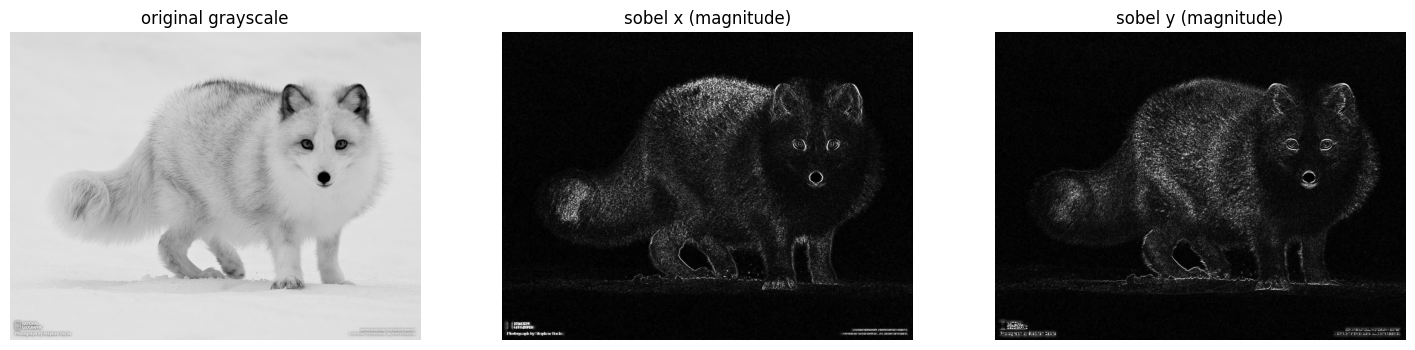

sobel x and y gradient magnitudes displayed.


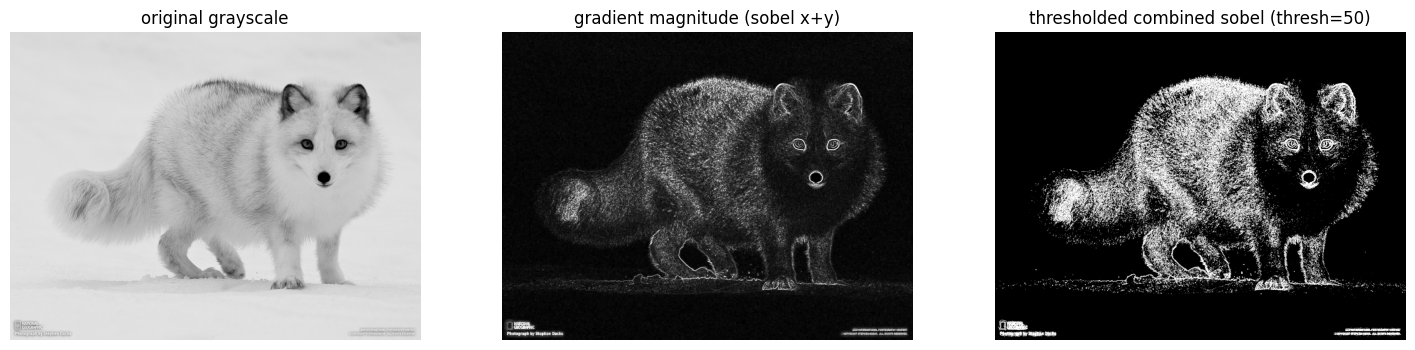

combined sobel gradient magnitude and its thresholded result displayed.


In [1]:
#lab 6 code
#task-
'''
input a image from user.
visualize the image in gray scale and color mode, acess pixel intensity values and print them,
chosse any one pixel and change it to random intensity value
histogram, thresholding, edge detection, object detection,
introduction of noise, gaussian kernel and sober kernel,
merging two Sobel kernel filter outputs and use thresholding or edge detection.
'''
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import io
import numpy as np

# image upload
print("please upload your image file. for example, 'my_image.jpg' or 'sample.png'.")
uploaded = files.upload()

if not uploaded:
    print("no file was uploaded. please try again.")
else:
    #get the name of the first uploaded file
    image_filename = list(uploaded.keys())[0]
    print(f"file '{image_filename}' uploaded successfully.")

    #write the uploaded file to a temporary location to be read by cv2.imread
    with open(image_filename, 'wb') as f:
        f.write(uploaded[image_filename])

    img = cv2.imread(image_filename)

    #check if the image was loaded successfully
    if img is None:
        print(f"error: could not load image '{image_filename}'. please ensure it's a valid image file.")
    else:
        print(f"image loaded successfully from {image_filename}. image shape: {img.shape}")

        #store the image path globally for subsequent steps
        global image_path
        image_path = image_filename #update image_path with the successfully loaded image file name

        #display the image for verification
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("loaded image")
        plt.axis("off")
        plt.show()

#visualize image modes
#convert the loaded image from bgr to rgb for correct display with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# onvert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#display both images side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('grayscale image')
plt.axis('off')

plt.show()
print("original and grayscale images displayed.")
height, width = gray_img.shape

print("accessing pixel intensity values from the grayscale image:")

#select a few arbitrary pixel coordinates
pixel_coords = [
    (0, 0),             #top-left corner
    (0, width - 1),     #top-right corner
    (height - 1, 0),    #bottom-left corner
    (height - 1, width - 1), #bottom-right corner
    (height // 2, width // 2) #center pixel
]

#access and print intensity values for each selected pixel
for r, c in pixel_coords:
    if 0 <= r < height and 0 <= c < width:
        intensity = gray_img[r, c]
        print(f"pixel at ({r}, {c}): intensity = {intensity}")
    else:
        print(f"pixel coordinate ({r}, {c}) is out of bounds for image of shape {gray_img.shape}.")

print("pixel intensity values accessed and printed.")

#modify a single pixel
#1 make a copy of the gray_img to avoid altering the original
#do this so that orignal is reserved for subsequesnt tasks
modified_gray_img = gray_img.copy()

#get image dimensions from the original gray_img
height, width = gray_img.shape

#2choose a specific pixel's coordinates (e.g., the center pixel)
pixel_row, pixel_col = height // 2, width // 2

#3generate a random integer between 0 and 255 (inclusive)
random_intensity = np.random.randint(0, 256) # 256 is exclusive, so it generates up to 255

print(f"original intensity of pixel ({pixel_row}, {pixel_col}): {gray_img[pixel_row, pixel_col]}")
print(f"new random intensity for pixel ({pixel_row}, {pixel_col}): {random_intensity}")

#4assign this random intensity value to the chosen pixel in the modified_gray_img
modified_gray_img[pixel_row, pixel_col] = random_intensity

#5 display the modified_gray_img
plt.figure(figsize=(8, 6))
plt.imshow(modified_gray_img, cmap='gray')
plt.title('grayscale image with modified pixel')
plt.axis('off')
plt.show()

print("grayscale image with a modified pixel displayed.")

# generate image histogram
hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
plt.figure(figsize=(10, 6))
plt.plot(hist, color='gray')
plt.title('grayscale image histogram')
plt.xlabel('pixel intensity')
plt.ylabel('frequency')
plt.legend(['grayscale'])
plt.xlim([0, 256])
plt.show()
print("grayscale image histogram displayed.")

#apply thresholding
#define a threshold value (e.g., 127)
thresh_value = 127

#apply cv2.threshold() to the gray_img
# he function returns two values: the optimal threshold found and the thresholded image
_, thresholded_img = cv2.threshold(gray_img, thresh_value, 255, cv2.THRESH_BINARY)

#display the original gray_img and the thresholded_img side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('original grayscale')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(thresholded_img, cmap='gray')
plt.title(f'thresholded image (threshold = {thresh_value})')
plt.axis('off')
plt.show()

print("thresholding applied and images displayed.")

#apply edge detection
#apply cv2.canny() to the gray_img
#choose appropriate low and high threshold values
low_threshold = 100
high_threshold = 200
edges = cv2.Canny(gray_img, low_threshold, high_threshold)

#display the original gray_img and the edges side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('original grayscale')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title(f'canny edges (low={low_threshold}, high={high_threshold})')
plt.axis('off')
plt.show()

print("canny edge detection applied and images displayed.")

#object detection (contour detection)
#take the thresholded_img as the input for contour detection.
#cv2.findcontours modifies the input image, so make a copy if needed later.
#here, we use a copy of thresholded_img
thresholded_img_copy = thresholded_img.copy()

#apply cv2.findcontours()
#se cv2.retr_external to retrieve only external contours
#use cv2.chain_approx_simple to compress horizontal, vertical, and diagonal segments
contours, _ = cv2.findContours(thresholded_img_copy, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#create a blank image or convert the original `img` (color) to rgb for drawing contours.
#it's usually better to draw contours on a color image.
#ensure img_rgb is available, which was defined earlier as cv2.cvtcolor(img, cv2.color_bgr2rgb)
#let's create a drawing canvas from the original color image (img_rgb) to preserve its color information.
image_with_contours = img_rgb.copy()

#draw the detected contours on the chosen image
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2) # -1 means draw all contours

#display the image with the drawn contours using matplotlib.pyplot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('original color image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(image_with_contours)
plt.title('detected contours')
plt.axis('off')
plt.show()

print(f"found {len(contours)} contours. image with detected contours displayed.")

#introduce noise to the image
#define parameters for gaussian noise
mean = 0
std_dev = 25 # standard deviation controls the intensity of the noise

#generate gaussian noise with the same shape as gray_img
#convert gray_img to float32 for calculations to avoid clipping issues
gray_img_float = gray_img.astype(np.float32)
noise = np.random.normal(mean, std_dev, gray_img_float.shape).astype(np.float32)

#add the generated noise to the gray_img
noisy_img = gray_img_float + noise

#clip the values to the valid range [0, 255] and convert back to uint8
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

#display the original gray_img and the noisy_img side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('original grayscale')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title(f'grayscale image with gaussian noise (std dev={std_dev})')
plt.axis('off')
plt.show()

print("gaussian noise introduced to the grayscale image and displayed.")

#apply gaussian kernel (blurring) filters
#define the kernel size for the gaussian blur
kernel_size = (5, 5)  # must be an odd number

#apply cv2.gaussianblur() to the noisy_img
# 0 for sigmax and sigmay means opencv calculates them based on kernel size
gaussian_blurred_img = cv2.GaussianBlur(noisy_img, kernel_size, 0)

#display the noisy_img and the gaussian_blurred_img side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title('noisy image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(gaussian_blurred_img, cmap='gray')
plt.title(f'gaussian blurred image (kernel={kernel_size})')
plt.axis('off')

#show the plots
plt.show()

print("gaussian blurring applied to the noisy image and displayed.")

#apply sobel kernel filters
#pply cv2.sobel() to the gray_img to find the gradient in the x direction
#use cv2.cv_64f for output depth to handle negative slopes
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3) # dx=1, dy=0, ksize is optional (default is 3)

#apply cv2.sobel() to the gray_img to find the gradient in the y direction
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3) # dx=0, dy=1

#convert the absolute values of sobelx and sobely back to uint8 for display
abssol_x = cv2.convertScaleAbs(sobelx)
abssol_y = cv2.convertScaleAbs(sobely)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('original grayscale')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(abssol_x, cmap='gray')
plt.title('sobel x (magnitude)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(abssol_y, cmap='gray')
plt.title('sobel y (magnitude)')
plt.axis('off')
plt.show()
print("sobel x and y gradient magnitudes displayed.")

#merging sobel kernel outputs and further processing
#combine sobelx and sobely to find the overall gradient magnitude
#sobelx and sobely are already in float64 format from previous steps
gradient_magnitude_float = cv2.magnitude(sobelx, sobely)

#convert to uint8 for display and further processing
gradient_magnitude = cv2.convertScaleAbs(gradient_magnitude_float)

#option 1: apply thresholding to gradient magnitude
#let's choose a threshold value, e.g., 50
combined_sobel_thresh_value = 50
_, thresholded_combined_sobel = cv2.threshold(gradient_magnitude, combined_sobel_thresh_value, 255, cv2.THRESH_BINARY)

#display the original gray_img, gradient_magnitude, and thresholded_combined_sobel side-by-side
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('original grayscale')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('gradient magnitude (sobel x+y)')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(thresholded_combined_sobel, cmap='gray')
plt.title(f'thresholded combined sobel (thresh={combined_sobel_thresh_value})')
plt.axis('off')
plt.show()
print("combined sobel gradient magnitude and its thresholded result displayed.")